In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assumptions
- We assume the data has already been cleaned properly and there is no missing data
- We assume no normality after looking at graphs of the data
- We remove Station 1 because of missing data
- We test at the 5% signficance level

In [2]:
# Download the data files
!rm *.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station2_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station3_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station4_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station5_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station6_Revised_Final_Data.csv

In [3]:
# List of stations
stations = {
    'Station2_Revised_Final_Data.csv': 'Station 2',
    'Station3_Revised_Final_Data.csv': 'Station 3',
    'Station4_Revised_Final_Data.csv': 'Station 4',
    'Station5_Revised_Final_Data.csv': 'Station 5',
    'Station6_Revised_Final_Data.csv': 'Station 6'
}

In [4]:
# Load and process data for each station
def load_rainfall_data(file, station_name, time = 'year', pivot = False):
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Date'}, inplace=True)
    
    if time == 'year':
        df['Group'] = df['Date'].dt.year
    elif time == 'month':
        df['Group'] = df['Date'].dt.to_period('M').astype(str)
    elif time == 'month_matrix':
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month_name()
        df['Month_num'] = df['Date'].dt.month
        monthly_totals = df.groupby(['Year', 'Month', 'Month_num'])['Ppt'].sum().reset_index()
        matrix = monthly_totals.pivot_table(index='Month', columns='Year', values='Ppt')
        ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                          'July', 'August', 'September', 'October', 'November', 'December']
        return matrix.reindex(ordered_months)
    else:
        raise ValueError("`by` must be 'year', 'month', or 'month_matrix'")

    totals = df.groupby('Group')['Ppt'].sum().reset_index()
    totals.columns = [time.title(), station_name]

    if pivot:
        return totals.set_index(time.title())
    return totals

In [5]:
# Merge all data into rainfall per year
rain_year_df = None
for file, name in stations.items():
    df = load_rainfall_data(file, name, time = 'year')
    rain_year_df = df if rain_year_df is None else pd.merge(rain_year_df, df, on = 'Year', how = 'outer')
rain_year_df.set_index('Year', inplace=True)

In [6]:
rain_year_df.head()

,Station 2,Station 3,Station 4,Station 5,Station 6
Year,,,,,
2015,800.38,942.71,755.58,810.71,731.69
2016,864.62,890.41,926.76,814.81,638.30
2017,528.76,649.38,629.81,620.43,441.23
2018,692.70,740.80,659.74,654.00,798.36
2019,501.91,558.57,485.00,441.59,458.35


In [7]:
# Merge all data into rainfall per month
rain_month_df = None
for file, name in stations.items():
    df = load_rainfall_data(file, name, time = 'month')
    rain_month_df = df if rain_month_df is None else pd.merge(rain_month_df, df, on = 'Month', how = 'outer')
rain_month_df.set_index('Month', inplace=True)

In [8]:
rain_month_df.head(10)

,Station 2,Station 3,Station 4,Station 5,Station 6
Month,,,,,
2015-01,76.89,75.15,56.00,71.56,42.87
2015-02,5.05,5.33,4.79,3.30,3.04
2015-03,48.13,53.26,60.07,61.65,49.46
2015-04,64.74,74.66,65.52,99.30,55.11
2015-05,245.06,264.86,208.24,230.35,243.82
2015-06,50.79,89.64,73.63,26.89,41.14
2015-07,2.03,17.27,0.00,0.00,5.58
2015-08,4.06,15.74,20.32,10.16,18.79
2015-09,16.00,14.48,5.82,10.41,6.60


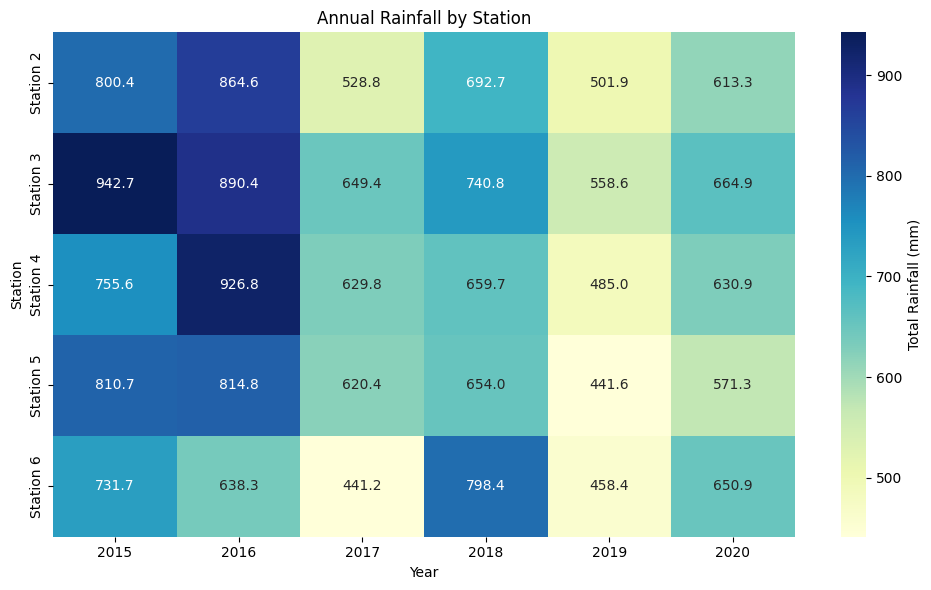

In [9]:
# Plot the heatmap by year
plt.figure(figsize=(10, 6))
sns.heatmap(rain_year_df.T, cmap = "YlGnBu", annot = True, fmt = ".1f", cbar_kws = {'label': 'Total Rainfall (mm)'})
plt.title("Annual Rainfall by Station")
plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.savefig("Annual_Rainfall_by_Station.pdf", format="pdf")
plt.show()

## Hypothesis Test: Two-Sample T-Tests Between Stations

This section performs **independent two-sample t-tests** between each unique pair of weather stations to determine whether their **average annual rainfall** differs significantly.

---

### Hypotheses

For each station pair \( A \) and \( B \):

- **Null Hypothesis (H₀)**:  
  The mean annual rainfall at Station A is equal to the mean annual rainfall at Station B.  

- **Alternative Hypothesis (H₁)**:  
  The mean annual rainfall at Station A is **not equal** to the mean at Station B.  

---

### Test Details

- **Test used**: Welch’s t-test, assuming unequal variances
- **Data**: Annual rainfall totals per station
- **Equal variances?** No
- **Significance level**: alpha = 0.05

---

### Results Interpretation

- Each row shows the comparison between two stations.
- The **p-value** tells us the probability of observing the data assuming the null hypothesis is true.
- If **p < 0.05**, the difference is considered **statistically significant**.
- In the current output:
  - **All p-values are > 0.05**
  - **We fail to reject the null hypothesis**
  - **Conclusion**: There is **no statistically significant difference** in average annual rainfall between any pair of stations.
  
---

### Conclusion

This suggests the rainfall patterns across the six stations are similar, at least at the annual level. This tells us that no station has statistically significantly more rainfall than another. This makes sense when looking at our heatmap because the annual rainfalls between stations seem similar.

In [10]:
from scipy.stats import ttest_ind
import itertools

results = []
for s1, s2 in itertools.combinations(rain_year_df.columns, 2):
    x = rain_year_df[s1].dropna()
    y = rain_year_df[s2].dropna()
    common = x.index.intersection(y.index)
    x_common = x.loc[common]
    y_common = y.loc[common]
    
    t_stat, p_val = ttest_ind(x_common, y_common, equal_var=False)
    
    results.append({
        "Station A": s1,
        "Station B": s2,
        "T-statistic": round(t_stat, 3),
        "P-value": round(p_val, 4),
        "Significant (p < 0.05)": "Yes" if p_val < 0.05 else "No"
    })

pd.DataFrame(results)


,Station A,Station B,T-statistic,P-value,Significant (p < 0.05)
0,Station 2,Station 3,-0.872,0.4038,No
1,Station 2,Station 4,-0.169,0.8693,No
2,Station 2,Station 5,0.177,0.8632,No
3,Station 2,Station 6,0.563,0.5859,No
4,Station 3,Station 4,0.698,0.5011,No
5,Station 3,Station 5,1.054,0.3169,No
6,Station 3,Station 6,1.436,0.1816,No
7,Station 4,Station 5,0.346,0.7368,No
8,Station 4,Station 6,0.729,0.4830,No
9,Station 5,Station 6,0.389,0.7053,No


## Mann-Kendall Trend Test: Annual Rainfall at Each Station

This section applies the **Mann-Kendall test** to detect long-term trends in annual rainfall at each station.

---

### What is the Mann-Kendall Test?

The **Mann-Kendall test** is a non-parametric method used to identify **monotonic trends** (consistently increasing or decreasing) in a time series without assuming any particular distribution.

It is ideal for detecting **climate trends** like changes in rainfall or temperature over time.

---

### Hypotheses (Per Station)

For each station's annual rainfall series:

- **Null Hypothesis (H₀)**:  
  There is **no monotonic trend** in rainfall over time.

- **Alternative Hypothesis (H₁)**:  
  There **is a monotonic trend** (either increasing or decreasing) in annual rainfall.

---

### Test Details

- **Library used**: `pymannkendall`
- **Test**: `mk.original_test()`
- **Input**: Annual rainfall values per station
- **Significance level**: alpha = 0.05

---

### Output Explanation

| Column     | Description                                             |
|------------|---------------------------------------------------------|
| **Station** | Name of the weather station                            |
| **Trend**   | `increasing`, `decreasing`, or `no trend`              |
| **P-value** | Probability that the observed trend is due to chance   |
| **Significant** | "Yes" if p < 0.05, indicating a statistically significant trend |

---

### Interpretation of Your Results

- All stations returned **"no trend"** with **p-values > 0.05**
- This means the analysis **did not detect any statistically significant trends** in annual rainfall at any station
- Possible reasons:
  - Annual variation is high
  - Not enough years of data to detect a slow-moving trend

---

This analysis complements linear regression by using a **robust, distribution-free method** to assess long-term rainfall patterns.


In [11]:
import pymannkendall as mk

trend_results = []

for station in rain_year_df.columns:
    series = rain_year_df[station].dropna()
    
    # Perform Mann-Kendall test
    result = mk.original_test(series)
    
    trend_results.append({
        'Station': station,
        'Trend': result.trend,
        'P-value': round(result.p, 4),
        'Significant (p < 0.05)': 'Yes' if result.p < 0.05 else 'No'
    })

# Display as DataFrame
trend_df = pd.DataFrame(trend_results)
pd.DataFrame(trend_df)

,Station,Trend,P-value,Significant (p < 0.05)
0,Station 2,no trend,0.2597,No
1,Station 3,no trend,0.1329,No
2,Station 4,no trend,0.2597,No
3,Station 5,no trend,0.1329,No
4,Station 6,no trend,1.0000,No


### Kruskal-Wallis Test Summary for Rainfall Comparisons

The **Kruskal-Wallis H-test** is a non-parametric alternative to the one-way ANOVA. It assesses whether samples originate from the same distribution, without assuming normality. This is useful when rainfall data is skewed or contains outliers.

---

#### **Hypotheses**
- **Null Hypothesis (H₀):** The distributions of rainfall are the same across all groups being compared.
- **Alternative Hypothesis (H₁):** At least one group differs in distribution from the others.

---


#### **Interpretation**
- The **non-significant result** for rainfall differences across stations (p = 0.5490) suggests no statistically significant difference in distribution between stations.
- The **significant result** across years (p = 0.0014) indicates that at least one year had a rainfall distribution that was significantly different from the others.
- This supports the idea that **temporal variation** (year-to-year changes) is more pronounced than spatial variation (between stations) in rainfall patterns.


In [12]:
from scipy.stats import kruskal

# 1. Kruskal-Wallis test across stations (all years)
station_groups = [rain_year_df[station].dropna().values for station in rain_year_df.columns]
kruskal_stations_stat, kruskal_stations_p = kruskal(*station_groups)

# 2. Kruskal-Wallis test across years (all stations)
year_groups = [rain_year_df.loc[year].dropna().values for year in rain_year_df.index]
kruskal_years_stat, kruskal_years_p = kruskal(*year_groups)

# Display results
kruskal_results = pd.DataFrame({
    'Test': ['Across Stations (all years)', 'Across Years (all stations)'],
    'H-statistic': [round(kruskal_stations_stat, 3), round(kruskal_years_stat, 3)],
    'P-value': [round(kruskal_stations_p, 4), round(kruskal_years_p, 4)],
    'Significant (p < 0.05)': ['Yes' if p < 0.05 else 'No' for p in [kruskal_stations_p, kruskal_years_p]]
})

print(kruskal_results)


                          Test  H-statistic  P-value Significant (p < 0.05)
0  Across Stations (all years)        2.146   0.7089                     No
1  Across Years (all stations)       23.219   0.0003                    Yes


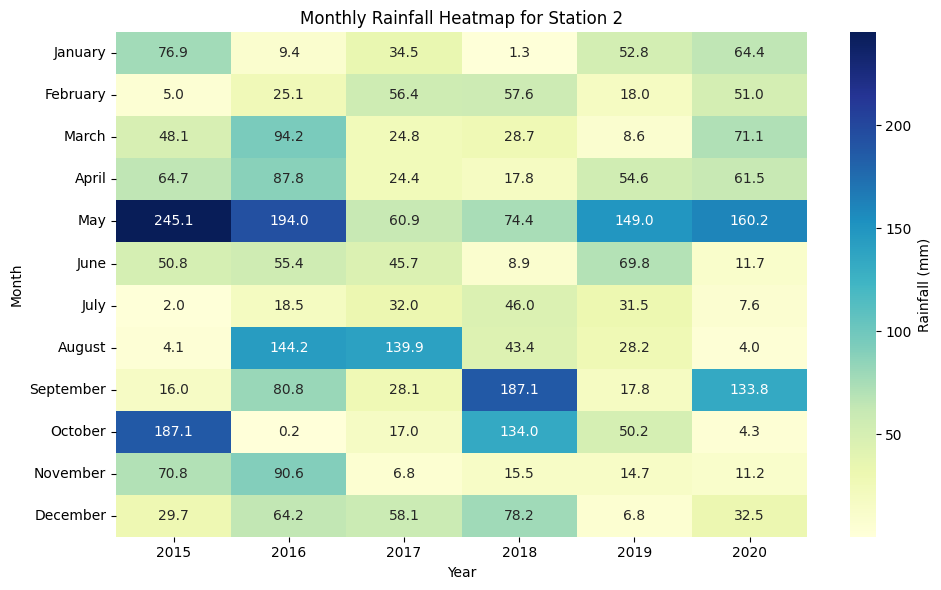

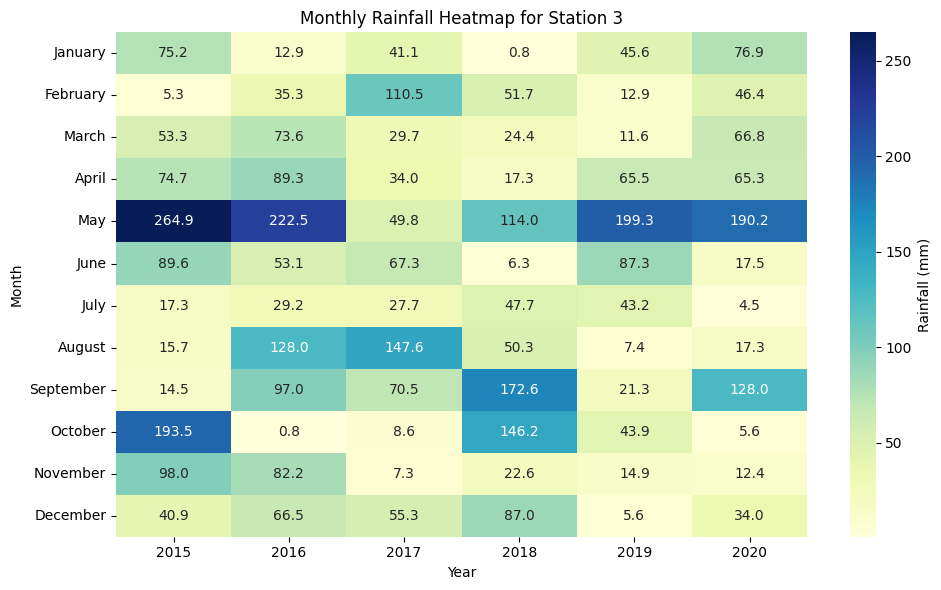

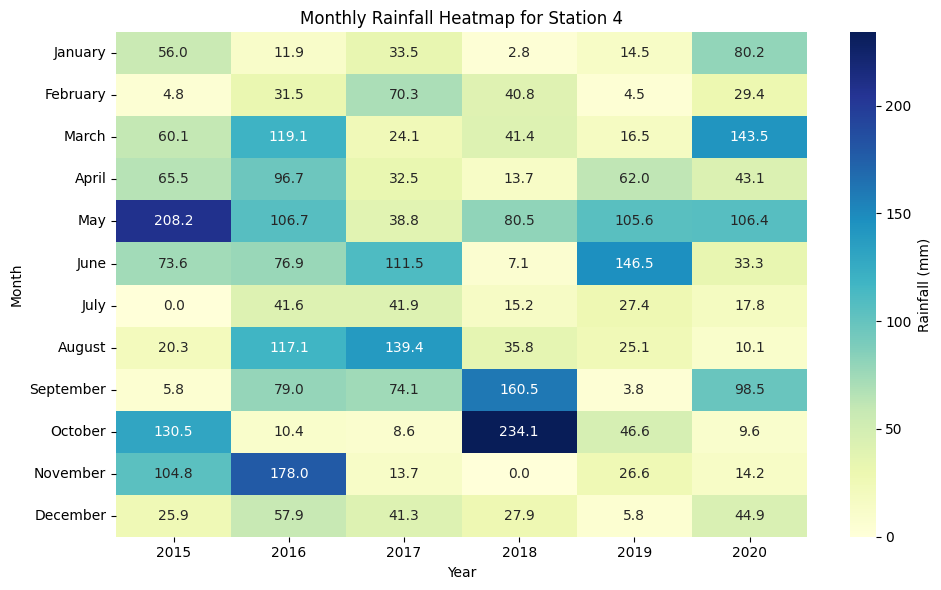

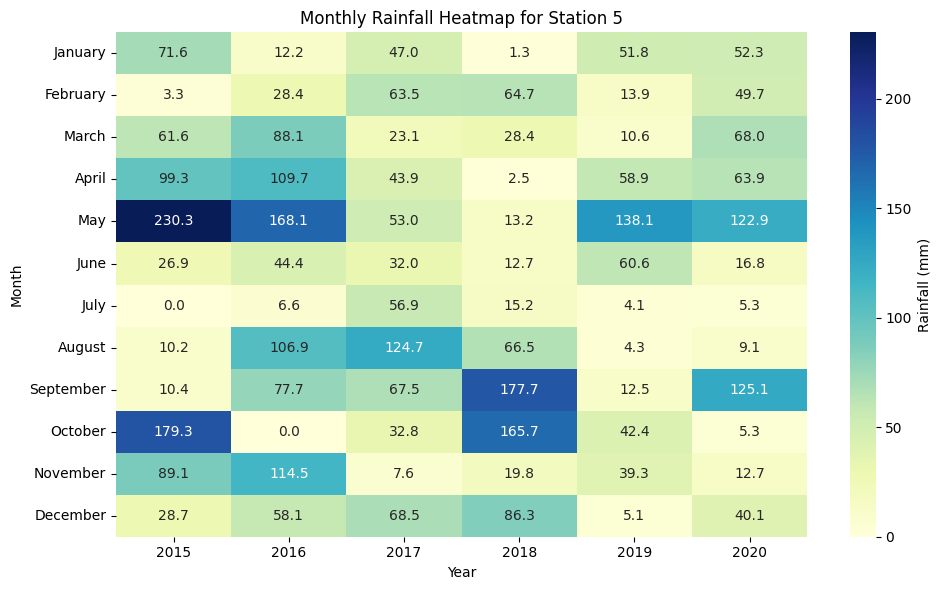

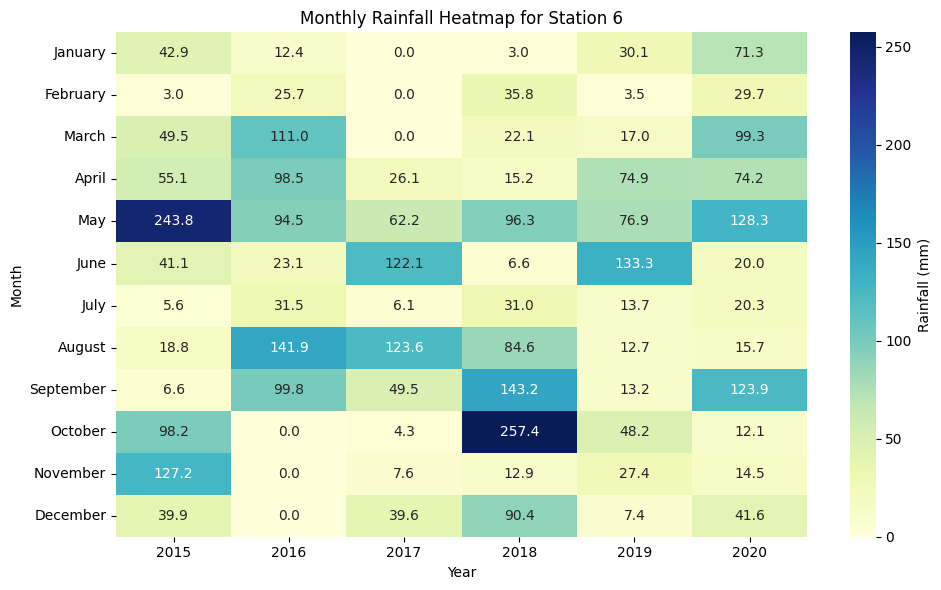

In [14]:
# Plot the heatmap for each station by month
for file, name in stations.items():
    matrix = load_rainfall_data(file, name, time = 'month_matrix')
    plt.figure(figsize = (10, 6))
    sns.heatmap(matrix, cmap = 'YlGnBu', annot = True, fmt = ".1f", cbar_kws = {'label': 'Rainfall (mm)'})
    plt.title(f'Monthly Rainfall Heatmap for {name}')
    plt.xlabel('Year')
    plt.ylabel('Month')
    plt.tight_layout()
    filename = f"Monthly_Rainfall_by_{name.replace(' ', '_')}.pdf"
    plt.savefig(filename, format="pdf")
    plt.show()

## Trend Analysis: Monthly Rainfall Over Time (Per Station)

This section uses **ordinary least squares (OLS) regression** to analyze whether monthly rainfall is increasing or decreasing over time at each station.

---

### Hypotheses (Per Station & Month)

For each station and each month (e.g., May at Station 3):

- **Null Hypothesis (H₀):**  
  There is **no trend** in rainfall over the years.  
  The slope of rainfall vs. year = 0.

- **Alternative Hypothesis (H₁):**  
  There is a **significant upward or downward trend** in rainfall.  
  The slope ≠ 0.

---

### Methodology

- For each station:
  - Extract the rainfall matrix by month and year using `.pivot_table()`.
  - For each month:
    - Fit a linear model: `Rainfall = β₀ + β₁ × Year`
    - Store the slope (β₁), p-value, and significance indicator
- Only months with at least 5 years of data are analyzed

---

### Results Interpretation

- **Slope**: Direction and rate of change in rainfall (mm/year)
  - Positive = rainfall is increasing
  - Negative = rainfall is decreasing
- **P-value**: Probability that the observed trend is due to chance
- **Significant (p < 0.05)**:
  - **Yes**: Evidence of a real increasing or decreasing trend
  - **No**: Cannot reject the null — no significant trend

---

### Key Findings

- Most month–station combinations showed **no statistically significant trends**.
- Only November at Station 3) had **p < 0.05**, suggesting isolated months with possible long-term shifts.
- Overall, **rainfall trends by month are not consistently significant across stations**, which may indicate high year-to-year variability or stable seasonal patterns.

---

This analysis helps identify subtle patterns in seasonal rainfall change — such as whether certain months are gradually becoming wetter or drier over the study period.


In [15]:
import statsmodels.api as sm
# Initialize container for results
monthly_trends = []

# Loop over each station
for file, name in stations.items():
    month_matrix = load_rainfall_data(file=file, station_name=name, time='month_matrix')

    for month in month_matrix.index:
        month_data = month_matrix.loc[month].dropna()

        if len(month_data) < 5:
            continue  # not enough years for trend analysis

        X = month_data.index.values.astype(int)
        X = sm.add_constant(X)
        y = month_data.values

        model = sm.OLS(y, X).fit()

        monthly_trends.append({
            'Station': name,
            'Month': month,
            'Slope': round(model.params[1], 3),
            'P-value': round(model.pvalues[1], 4),
            'Significant (p < 0.05)': 'Yes' if model.pvalues[1] < 0.05 else 'No'
        })

# Convert to DataFrame
monthly_trends_df = pd.DataFrame(monthly_trends)
significant_trends_df = monthly_trends_df[monthly_trends_df["Significant (p < 0.05)"] == "Yes"]

# Display or export
pd.DataFrame(monthly_trends_df)

,Station,Month,Slope,P-value,Significant (p < 0.05)
0,Station 2,January,0.991,0.9083,No
1,Station 2,February,5.987,0.3122,No
2,Station 2,March,-3.945,0.6596,No
3,Station 2,April,-3.509,0.6343,No
4,Station 2,May,-15.590,0.4131,No
5,Station 2,June,-5.406,0.4198,No
6,Station 2,July,2.305,0.6190,No
7,Station 2,August,-12.705,0.4748,No
8,Station 2,September,15.970,0.4038,No
9,Station 2,October,-18.495,0.3751,No


## Autocorrelation Test for Seasonality (ACF)

This section uses the **autocorrelation function (ACF)** to detect seasonal patterns in monthly rainfall data at each station.

---

### Why Use ACF?

The ACF helps identify whether rainfall patterns repeat at regular intervals — for example, **every 12 months**, which would indicate **annual seasonality**.

---

### Method

- Monthly rainfall matrices were flattened into 1D time series (month-by-month over years).
- The **autocorrelation at lag 12** was extracted to check for annual patterns.
- A correlation at lag 12 greater than the 95% confidence threshold was marked as **"Seasonal Signal: Yes"**.

---

### Output Table Columns

| Column            | Meaning                                              |
|-------------------|------------------------------------------------------|
| **Station**        | The rainfall station being analyzed                 |
| **Lag 12 ACF**     | Autocorrelation value at 12-month lag               |
| **Seasonal Signal**| Yes/No based on statistical threshold               |

---

### Interpretation

- **Yes** in the "Seasonal Signal" column suggests the station has recurring yearly rainfall patterns.
- **No** suggests **no strong or consistent seasonality** in rainfall.

This analysis gives a quick statistical check for seasonal dynamics at each location before deeper modeling.


<Figure size 1000x400 with 0 Axes>

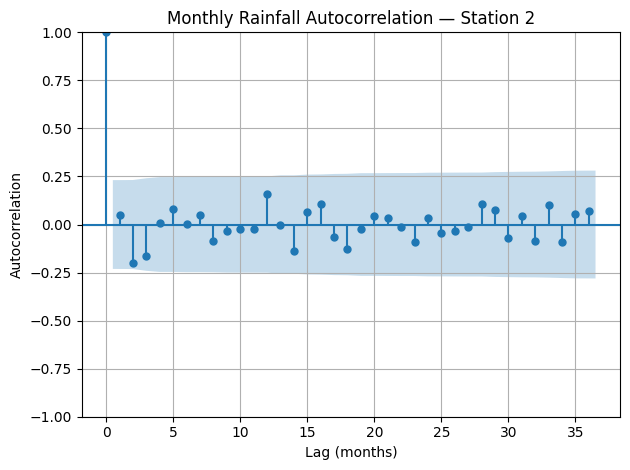

<Figure size 1000x400 with 0 Axes>

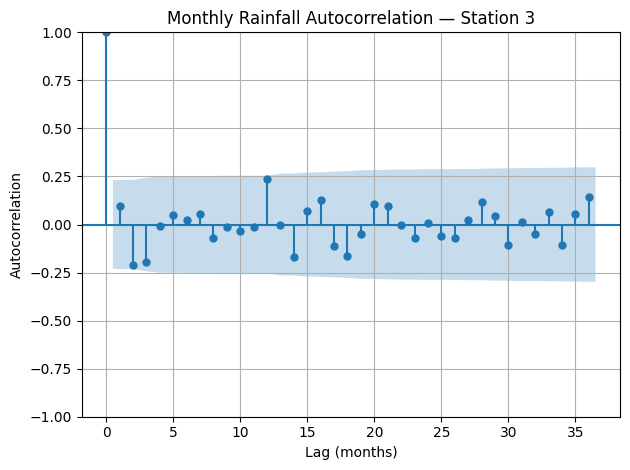

<Figure size 1000x400 with 0 Axes>

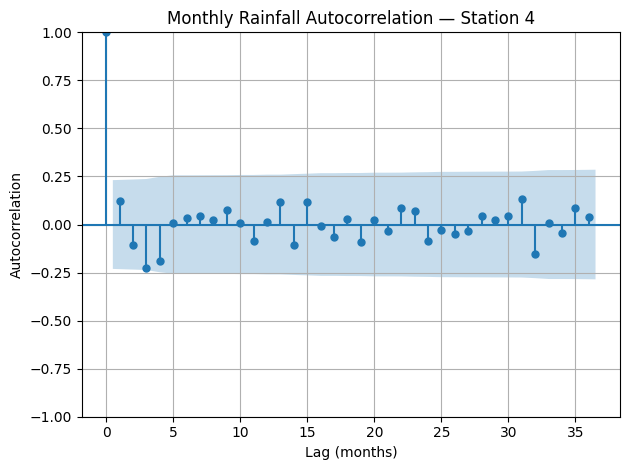

<Figure size 1000x400 with 0 Axes>

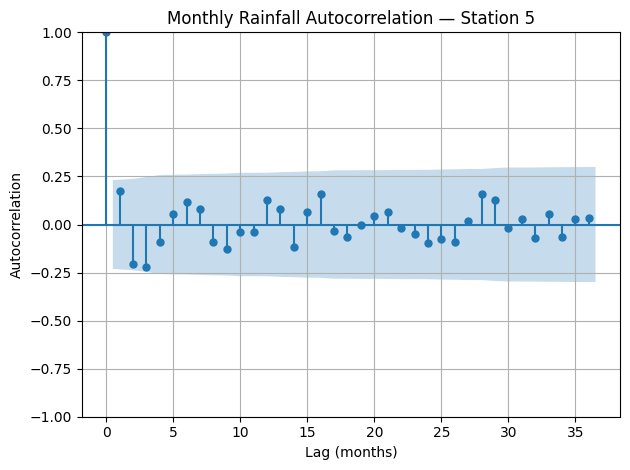

<Figure size 1000x400 with 0 Axes>

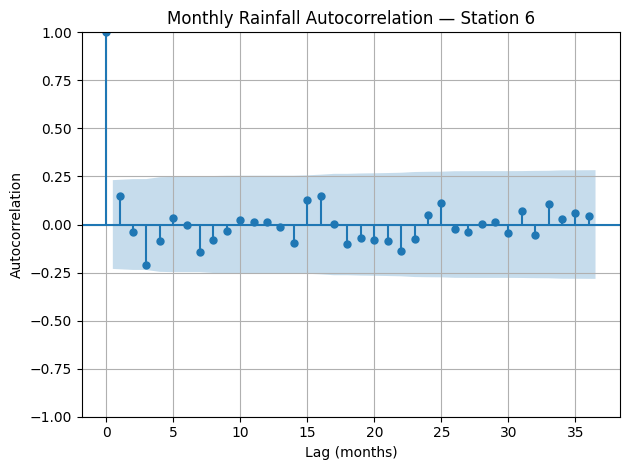

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Loop through each station and generate ACF plot for monthly rainfall
for file, station_name in stations.items():
    # Load monthly rainfall matrix (rows = months, cols = years)
    month_matrix = load_rainfall_data(file=file, station_name=station_name, time='month_matrix')
    
    # Skip if not enough data
    if month_matrix.empty or month_matrix.shape[1] < 3:
        print(f"Skipping {station_name} — insufficient data.")
        continue

    # Convert matrix into a 1D time series (month-by-month across years)
    monthly_series = month_matrix.T.values.flatten()
    monthly_series = pd.Series(monthly_series).dropna()

    # Plot ACF
    plt.figure(figsize=(10, 4))
    plot_acf(monthly_series, lags=36)  # Lags = months (3 years)
    plt.title(f"Monthly Rainfall Autocorrelation — {station_name}")
    plt.xlabel("Lag (months)")
    plt.ylabel("Autocorrelation")
    plt.grid(True)
    plt.tight_layout()
    filename = f"Monthly_Rainfall_Autocorrelation_{station_name.replace(' ', '_')}.pdf"
    plt.savefig(filename, format="pdf")
    plt.show()


## Kruskal-Wallis H Test: Monthly Rainfall Variation Across Stations

### Objective

To assess whether the **distribution of monthly rainfall** differs significantly across stations for each month of the year.

---

### Hypotheses (Per Month)

- **Null Hypothesis (H₀):** The distributions of rainfall across all stations are the same.
- **Alternative Hypothesis (H₁):** At least one station has a different distribution of rainfall for that month.

---

### Interpretation

None of the months showed statistically significant differences in rainfall distributions across stations (all p-values > 0.05). This implies that, based on the Kruskal-Wallis test, **there is no evidence that monthly rainfall differs across stations** for any specific month.

This aligns with the earlier findings that rainfall variability is not significantly different across locations, possibly due to regional coherence in weather systems.

In [17]:
from scipy.stats import kruskal
import pandas as pd

# Container for results
kruskal_results = []

# Ordered list of months
months_ordered = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']

# Loop through each month
for month in months_ordered:
    month_values = []

    # Collect rainfall data for this month from each station
    for file, name in stations.items():
        matrix = load_rainfall_data(file=file, station_name=name, time='month_matrix')

        if month in matrix.index:
            data = matrix.loc[month].dropna()
            if not data.empty:
                month_values.append(data.values)

    # Only run test if we have 2+ groups
    if len(month_values) > 1:
        h_stat, p_val = kruskal(*month_values)
        kruskal_results.append({
            "Month": month,
            "H-statistic": round(h_stat, 3),
            "P-value": round(p_val, 4),
            "Significant (p < 0.05)": "Yes" if p_val < 0.05 else "No"
        })

# Convert to DataFrame
kruskal_df = pd.DataFrame(kruskal_results)

print(kruskal_df)

        Month  H-statistic  P-value Significant (p < 0.05)
0     January        1.316   0.8587                     No
1    February        4.249   0.3733                     No
2       March        0.563   0.9670                     No
3       April        0.830   0.9344                     No
4         May        2.920   0.5712                     No
5        June        2.903   0.5741                     No
6        July        3.232   0.5199                     No
7      August        0.629   0.9598                     No
8   September        0.611   0.9619                     No
9     October        0.198   0.9954                     No
10   November        0.853   0.9312                     No
11   December        1.477   0.8308                     No


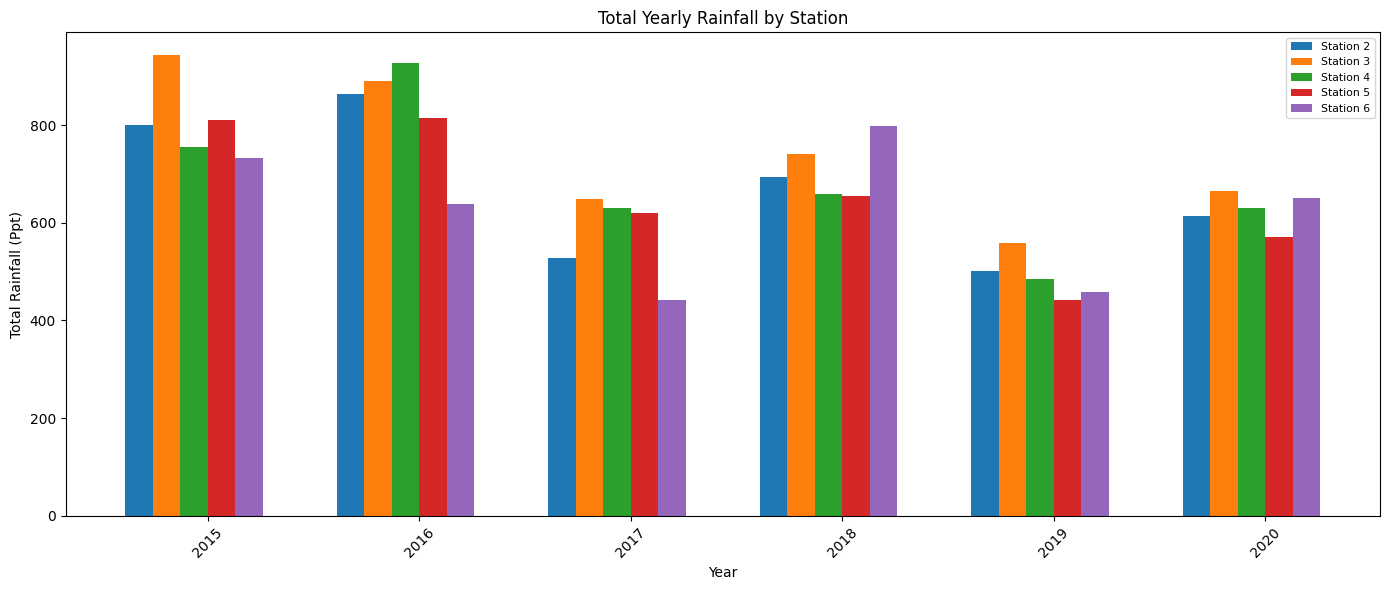

In [18]:
# Plotting variables
bar_width = 0.13
years = rain_year_df.index
x = np.arange(len(years))  # base x locations for groups
plt.figure(figsize=(14, 6))

# Loop through each station and plot its bars offset
for i, station in enumerate(rain_year_df.columns):
    plt.bar(x + i * bar_width, rain_year_df[station], width=bar_width, label=station)

# Labeling
plt.xlabel('Year')
plt.ylabel('Total Rainfall (Ppt)')
plt.title('Total Yearly Rainfall by Station')
plt.xticks(x + bar_width * 2.5, years, rotation=45)  # center ticks
plt.legend(fontsize = 7.8)
plt.tight_layout()
plt.savefig("Total_Yearly_Rainfall_by_Station.pdf", format='pdf')
plt.show()

# Hypothesis Test 1: ANOVA – Monthly Rainfall Variation for Each Station

### Objective
The goal of this analysis is to determine whether monthly rainfall varies significantly within each station over time. We use a one-way ANOVA for each station to evaluate whether average rainfall differs by month.

---

### Why ANOVA?
ANOVA (Analysis of Variance) is appropriate when comparing the means across three or more independent groups—in this case, the 12 months of the year. A one-way ANOVA tests whether at least one month's mean rainfall differs from the others. It’s more robust and statistically valid than conducting multiple t-tests across months, which would increase the risk of Type I error.

---

### Hypotheses:
For each individual station:
- Null Hypothesis (H₀): 
    Mean monthly rainfall is the same across all months.
- Alternative Hypothesis (H₁): 
    At least one month has a different mean rainfall.

---

### Type of Test
We apply a one-way ANOVA to each station’s monthly rainfall totals. This test compares means across multiple groups (months) within a single station.

---

### Interpretation
Here are the ANOVA test results for each station:
- Station 2: F = 2.8991, p = 0.0040 → Statistically significant (p < 0.05)
- Station 3: F = 3.7056, p = 0.0005 → Statistically significant (p < 0.05)
- Station 4: F = 1.3310, p = 0.2303 → Not statistically significant (p > 0.05)
- Station 5: F = 1.9549, p = 0.0497 → Statistically significant (p < 0.05)
- Station 6: F = 1.8638, p = 0.0628 → Not statistically significant (p > 0.05)
These results indicate that there are statistically significant differences in rainfall across months for Stations 2, 3, and 5. This may reflect seasonality or localized weather patterns (e.g., wet and dry seasons). Other stations show no strong monthly differentiation, suggesting more even rainfall throughout the year.

---

### Conclusion
Monthly rainfall patterns differ significantly in half of the stations, indicating that some areas experience stronger seasonality or rainfall clustering in certain months. However, the lack of significant differences in the remaining stations suggests that not all locations follow the same temporal pattern. This mixed behavior could be driven by subtle geographic or atmospheric influences affecting local precipitation cycles.

In [30]:
from scipy.stats import f_oneway

# Load monthly totals in matrix format for Station 2
jan_matrix = load_rainfall_data("Station2_Revised_Final_Data.csv", "Station 2", time='month_matrix')

# Drop any months with missing data
jan_matrix_clean = jan_matrix.dropna()

# Perform one-way ANOVA across all months (each row is a month, columns are years)
anova_result = f_oneway(*[jan_matrix_clean.loc[month].dropna().values for month in jan_matrix_clean.index])

print("=== ANOVA: Monthly Rainfall Variation for Each Station ===")
for file, name in stations.items():
    df = load_rainfall_data(file, name, time='month')
    df['Month'] = pd.to_datetime(df['Month']).dt.month  # Extract numeric month
    grouped = df.groupby('Month')[name].apply(list)  # List of rainfall values per month
    anova_input = [group for group in grouped if len(group) > 1]
    
    if len(anova_input) < 2:
        print(f"{name}: Not enough data for ANOVA.")
        continue

    f_stat, p_val = f_oneway(*anova_input)
    result = "Significant difference (Reject H₀)" if p_val < 0.05 else "No significant difference (Fail to reject H₀)"
    print(f"{name}: F = {f_stat:.4f}, p = {p_val:.4f} → {result}")

=== ANOVA: Monthly Rainfall Variation for Each Station ===
Station 2: F = 2.8991, p = 0.0040 → Significant difference (Reject H₀)
Station 3: F = 3.7056, p = 0.0005 → Significant difference (Reject H₀)
Station 4: F = 1.3310, p = 0.2303 → No significant difference (Fail to reject H₀)
Station 5: F = 1.9549, p = 0.0497 → Significant difference (Reject H₀)
Station 6: F = 1.8638, p = 0.0628 → No significant difference (Fail to reject H₀)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8e560f6b-1726-4372-a865-7294f65e8413' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>